# 🛒 Superstore Sales — Exploratory Data Analysis
**Goal:** Understand sales performance, identify trends, and extract business insights.

**Dataset:** [Kaggle - Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

**Skills demonstrated:** Data cleaning, univariate & multivariate analysis, time-series trends, business insight storytelling.

## 0. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load the Data
> Download the dataset from Kaggle and place `Sample - Superstore.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(f'Shape: {df.shape}')
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Initial Inspection

In [3]:
# Column names, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Summary statistics for numeric columns
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [5]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values ✅')

Missing values per column:
No missing values ✅


In [6]:
# Check for duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


## 3. Data Cleaning

In [7]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Extract useful time features
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter

# Shipping duration in days
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print('Date columns parsed and features extracted ✅')
df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Order Quarter', 'Ship Days']].head()

Date columns parsed and features extracted ✅


,Order Date,Ship Date,Order Year,Order Month,Order Quarter,Ship Days
0,2016-11-08,2016-11-11,2016,11,4,3
1,2016-11-08,2016-11-11,2016,11,4,3
2,2016-06-12,2016-06-16,2016,6,2,4
3,2015-10-11,2015-10-18,2015,10,4,7
4,2015-10-11,2015-10-18,2015,10,4,7


## 4. Univariate Analysis — Understanding Each Variable

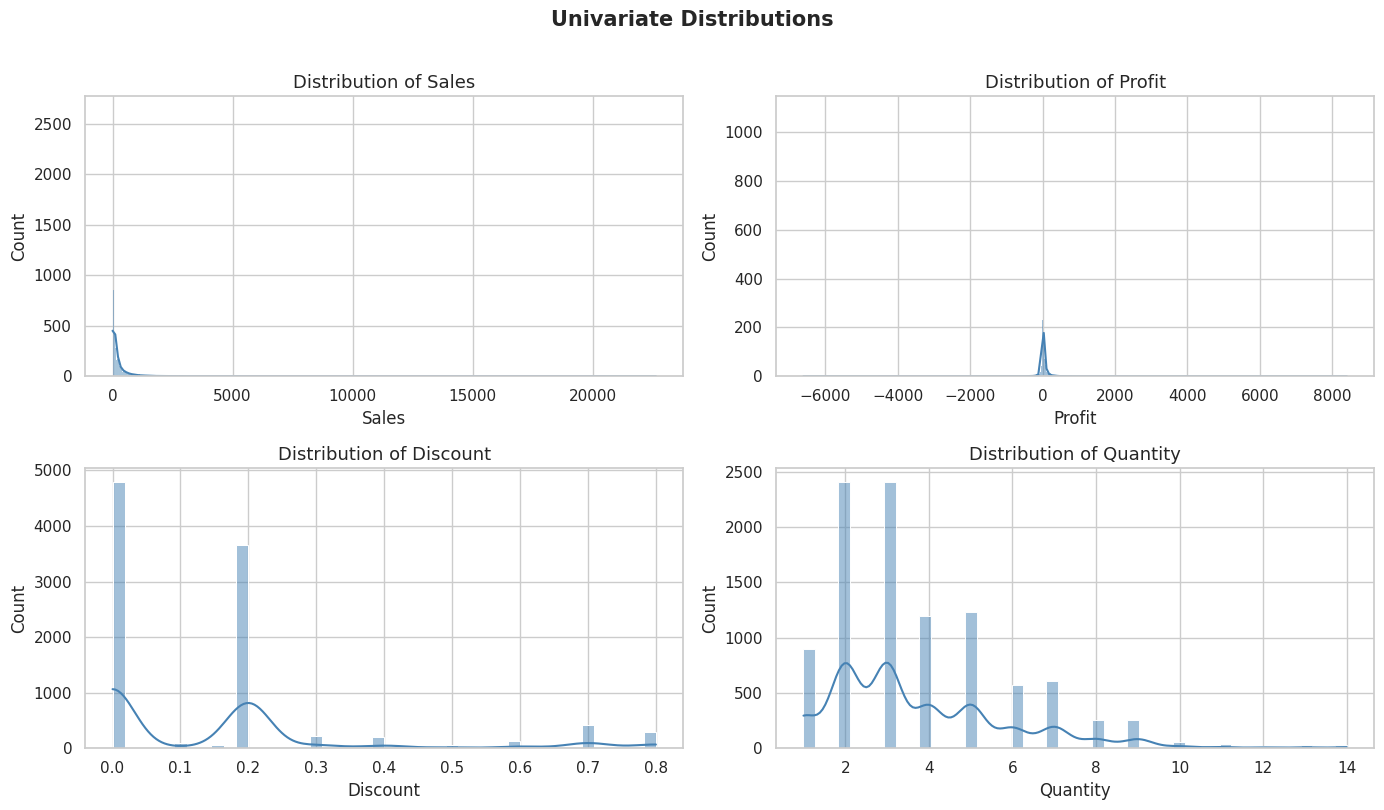

In [8]:
# Distribution of Sales, Profit, Discount, Quantity
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ['Sales', 'Profit', 'Discount', 'Quantity']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel(col)

plt.suptitle('Univariate Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

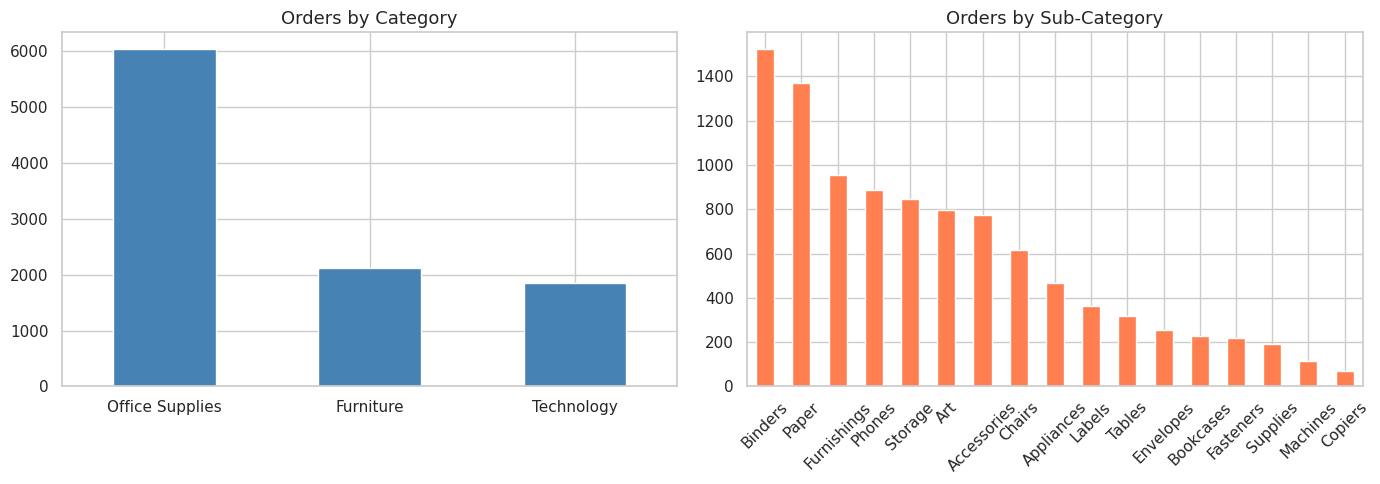

In [9]:
# Category & Sub-Category counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Orders by Category', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['Sub-Category'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Orders by Sub-Category', fontsize=13)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

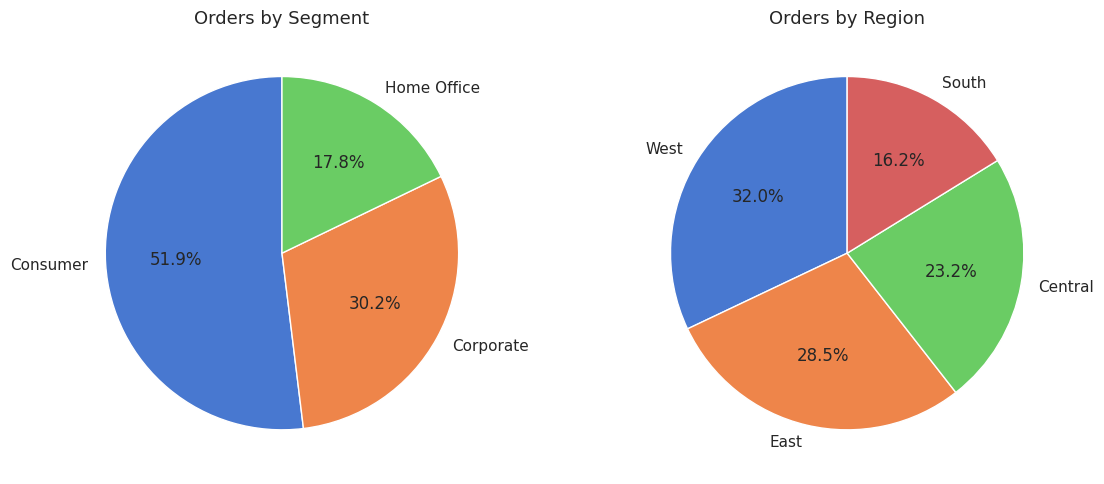

In [10]:
# Segment & Region distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], startangle=90)
axes[0].set_title('Orders by Segment', fontsize=13)
axes[0].set_ylabel('')

df['Region'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], startangle=90)
axes[1].set_title('Orders by Region', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Sales & Profit Analysis

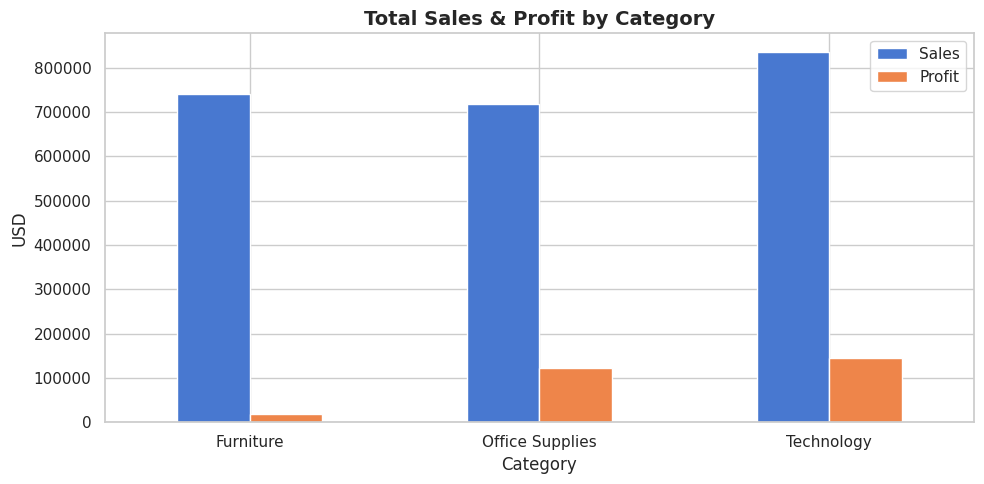

,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


In [11]:
# Total Sales and Profit by Category
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

cat_summary.set_index('Category').plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('Total Sales & Profit by Category', fontsize=14, fontweight='bold')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cat_summary

In [12]:
# Profit Margin by Category
cat_summary['Profit Margin %'] = (cat_summary['Profit'] / cat_summary['Sales'] * 100).round(2)
print(cat_summary[['Category', 'Profit Margin %']])

          Category  Profit Margin %
0        Furniture             2.49
1  Office Supplies            17.04
2       Technology            17.40


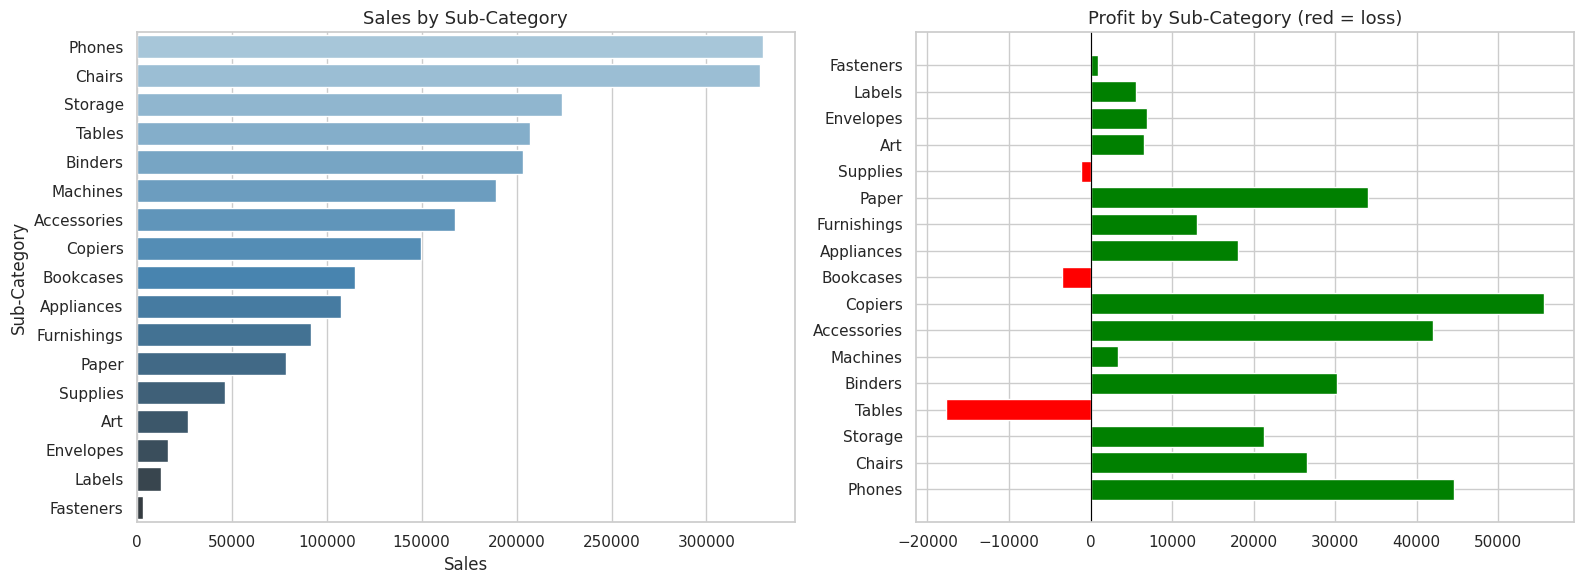

In [13]:
# Sales & Profit by Sub-Category
sub_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=sub_summary, x='Sales', y='Sub-Category', ax=axes[0], palette='Blues_d')
axes[0].set_title('Sales by Sub-Category', fontsize=13)

colors = ['green' if x > 0 else 'red' for x in sub_summary['Profit']]
axes[1].barh(sub_summary['Sub-Category'], sub_summary['Profit'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit by Sub-Category (red = loss)', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Time-Series Analysis — Sales Over Time

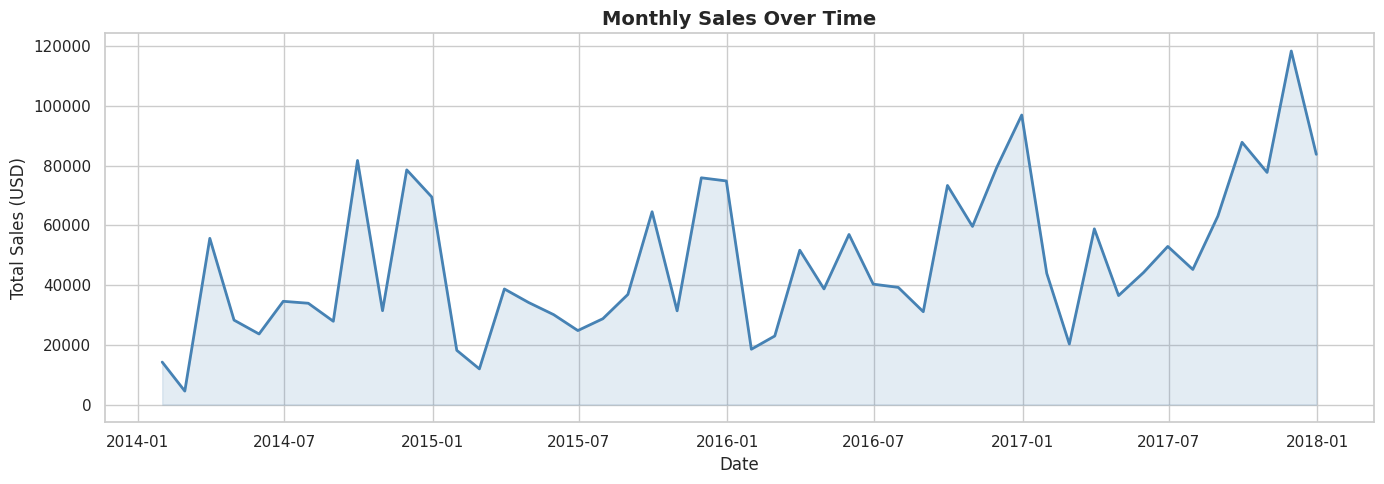

In [14]:
# Monthly Sales trend
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], color='steelblue', linewidth=2)
plt.fill_between(monthly_sales['Order Date'], monthly_sales['Sales'], alpha=0.15, color='steelblue')
plt.title('Monthly Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.show()

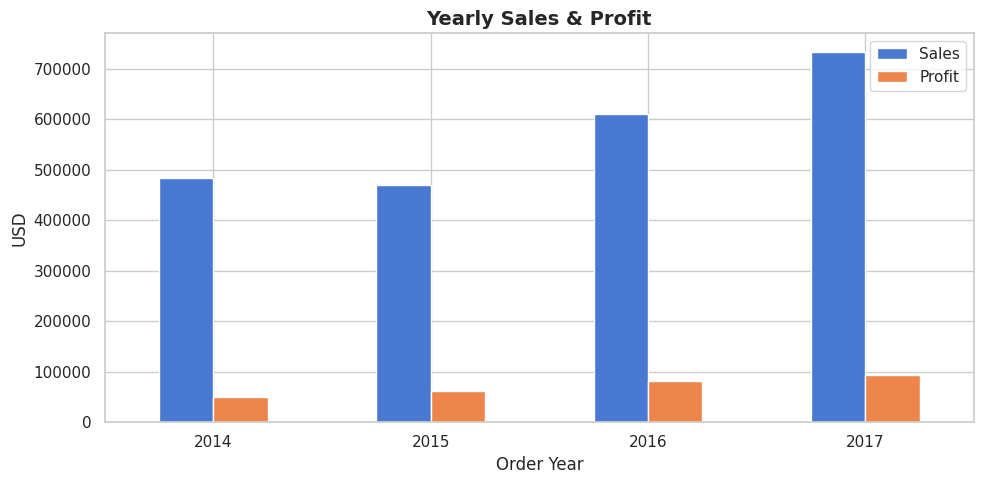

,Order Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


In [15]:
# Yearly Sales & Profit
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()

yearly.set_index('Order Year').plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('Yearly Sales & Profit', fontsize=14, fontweight='bold')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

yearly

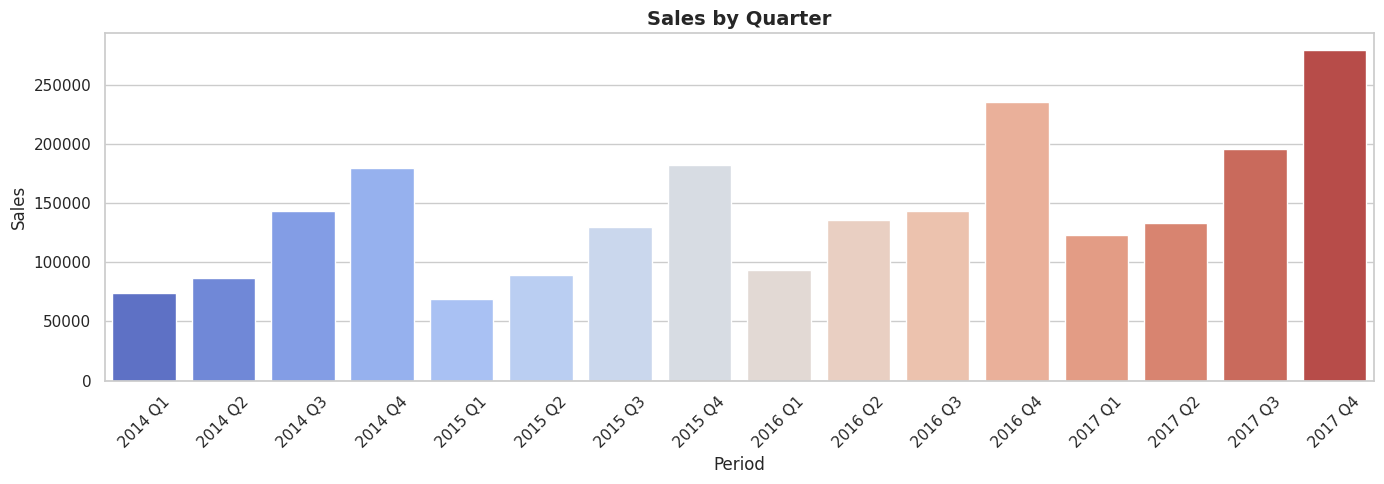

In [16]:
# Sales by Quarter (seasonality)
quarterly = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().reset_index()
quarterly['Period'] = quarterly['Order Year'].astype(str) + ' Q' + quarterly['Order Quarter'].astype(str)

plt.figure(figsize=(14, 5))
sns.barplot(data=quarterly, x='Period', y='Sales', palette='coolwarm')
plt.title('Sales by Quarter', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Regional & State Analysis

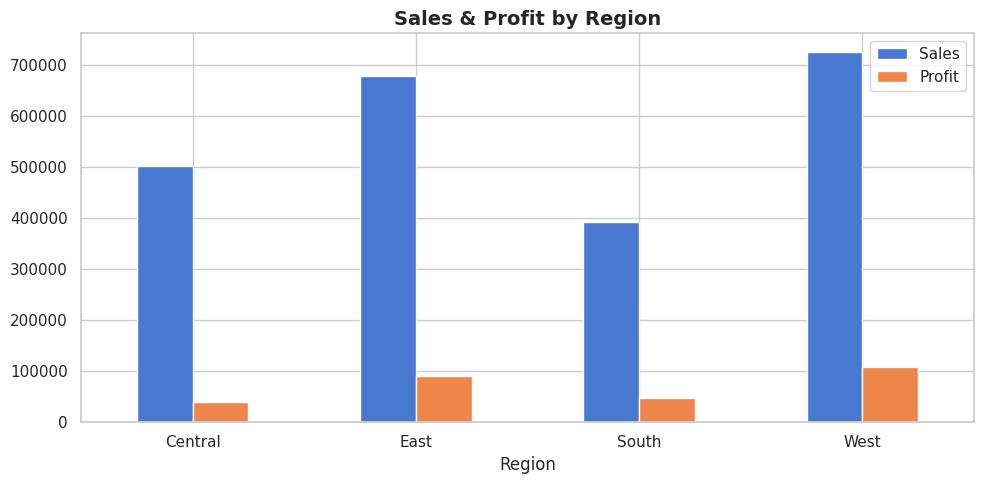

In [17]:
# Sales & Profit by Region
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

region_summary.set_index('Region').plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('Sales & Profit by Region', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

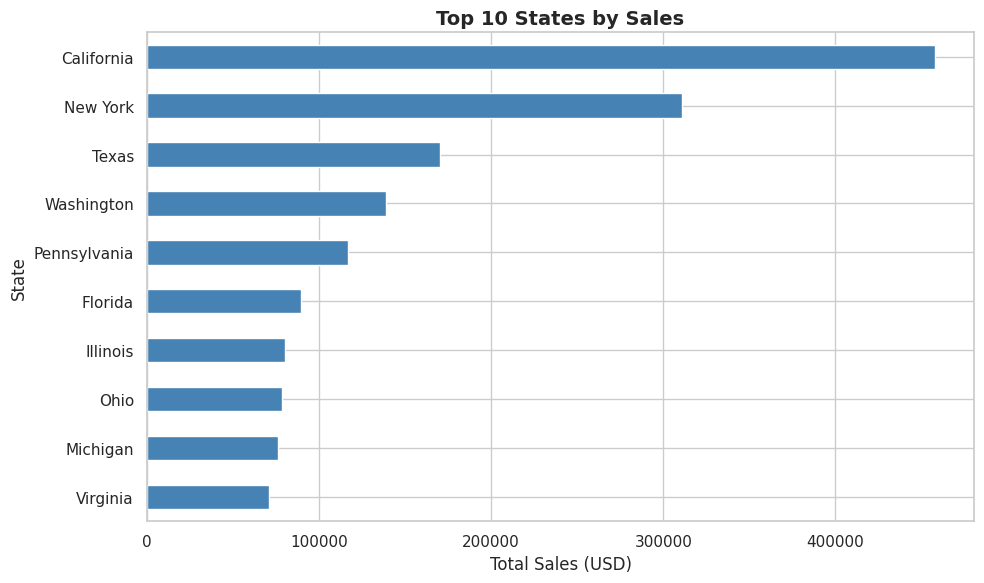

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Texas,170188.0458,-25729.3563
Washington,138641.2700,33402.6517
Pennsylvania,116511.9140,-15559.9603
Florida,89473.7080,-3399.3017
Illinois,80166.1010,-12607.8870
Ohio,78258.1360,-16971.3766
Michigan,76269.6140,24463.1876


In [18]:
# Top 10 States by Sales
top_states = df.groupby('State')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False).head(10)

top_states['Sales'].plot(kind='barh', figsize=(10, 6), color='steelblue', edgecolor='white')
plt.title('Top 10 States by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_states

## 8. Discount Impact Analysis

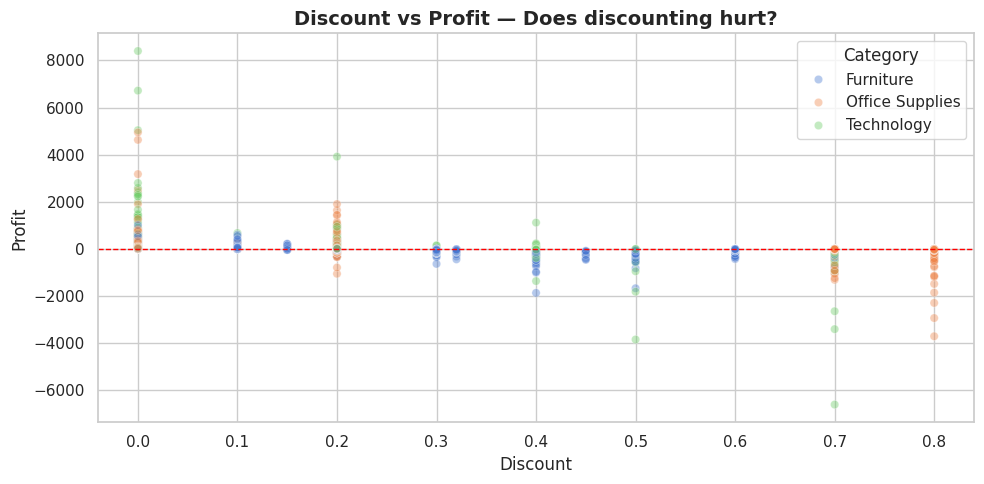

In [19]:
# Scatter: Discount vs Profit
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, hue='Category')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit — Does discounting hurt?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

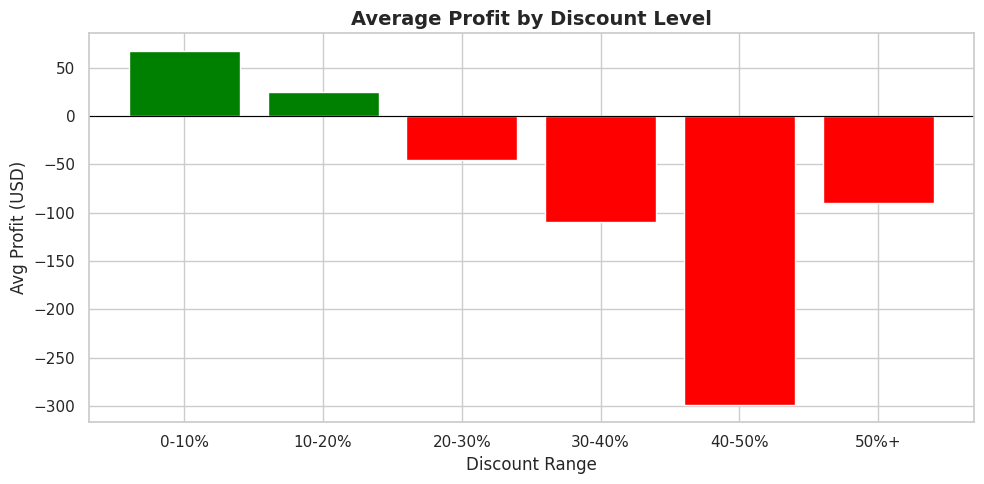

In [20]:
# Average Profit by Discount bucket
df['Discount Bucket'] = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                                labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'],
                                include_lowest=True)

discount_profit = df.groupby('Discount Bucket')['Profit'].mean().reset_index()

colors = ['green' if x > 0 else 'red' for x in discount_profit['Profit']]
plt.figure(figsize=(10, 5))
plt.bar(discount_profit['Discount Bucket'].astype(str), discount_profit['Profit'], color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
plt.xlabel('Discount Range')
plt.ylabel('Avg Profit (USD)')
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

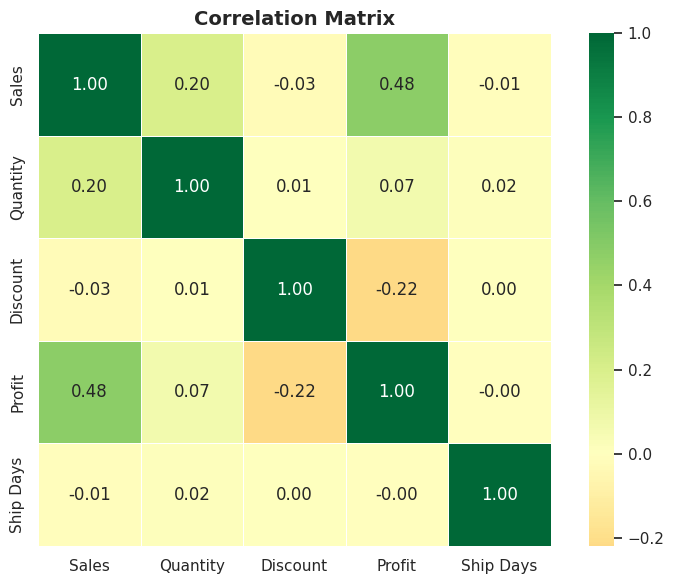

In [21]:
# Correlation heatmap of numeric features
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Shipping Analysis

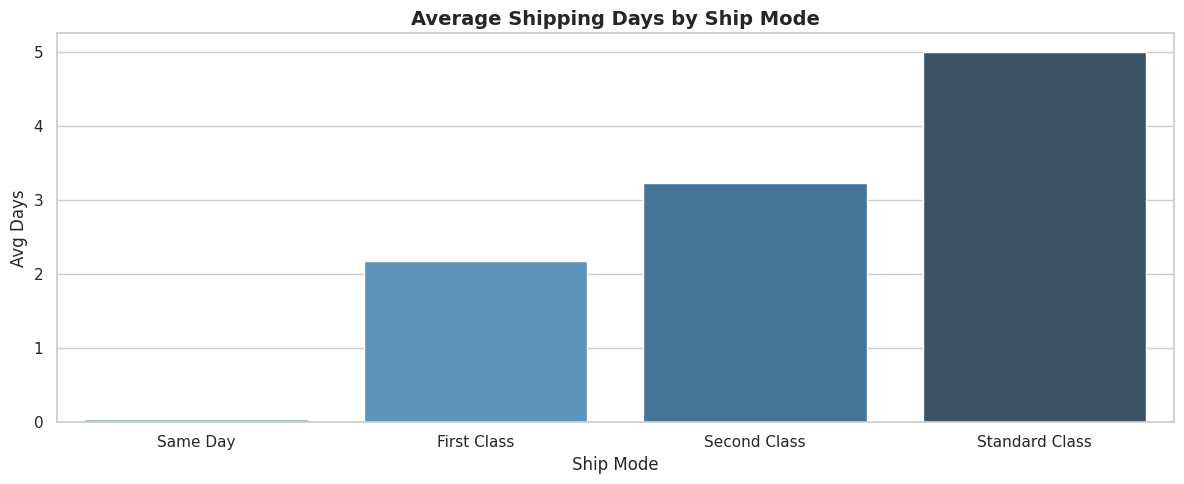

In [22]:
# Average ship days by Ship Mode
ship_summary = df.groupby('Ship Mode')['Ship Days'].mean().sort_values().reset_index()

sns.barplot(data=ship_summary, x='Ship Mode', y='Ship Days', palette='Blues_d')
plt.title('Average Shipping Days by Ship Mode', fontsize=14, fontweight='bold')
plt.ylabel('Avg Days')
plt.tight_layout()
plt.show()

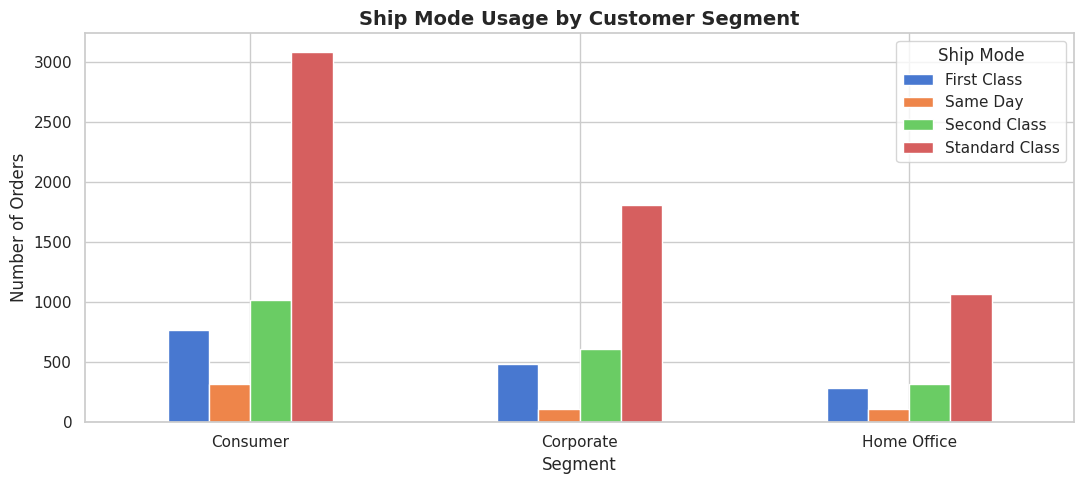

In [23]:
# Ship mode usage by segment
ship_seg = df.groupby(['Segment', 'Ship Mode']).size().unstack(fill_value=0)

ship_seg.plot(kind='bar', figsize=(11, 5), edgecolor='white')
plt.title('Ship Mode Usage by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Top & Bottom Performers

In [26]:
# Top 10 most profitable products
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print('Top 10 Most Profitable Products:')
print(top_products.to_string())

Top 10 Most Profitable Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360


In [25]:
# Bottom 10 least profitable products (biggest losses)
bottom_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
print('Bottom 10 Least Profitable Products (Losses):')
print(bottom_products.to_string())

Bottom 10 Least Profitable Products (Losses):
Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375


## 12. Key Business Insights

1. **Category Performance:** Technology leads in both sales and profit, making it the core revenue driver. Furniture generates strong sales but nearly no profit, suggesting a pricing or cost structure problem. Office Supplies punches above its weight with solid margins despite lower sales volume.
2. **Loss-Making Sub-Categories:** Tables, Bookcases, and Supplies are operating at a loss. Tables is the biggest concern. These need urgent pricing review or cost reduction.
3. **Seasonality:** Sales consistently peak in Q4 and in months March and October/November. The business should increase inventory and marketing spend ahead of these periods.
4. **Discounting Problem:** Discounts above 20% push profit into negative territory. The current discounting strategy is hurting the business — a cap of 20% should be enforced.
5. **Regional Performance:** West is the strongest region in both sales and profit. Central underperforms on profit despite decent sales — similar to the Furniture problem, likely a discounting or product mix issue.
6. **Shipping:** Standard Class dominates usage at ~5 days. Same Day is barely used — worth investigating if the price point is too high.